# Fire Simulation Surrogate Model - Evaluation & Visualization

This notebook provides comprehensive evaluation and visualization of trained surrogate models:

1. **Pure Surrogate Metrics**: MSE, MAE, RMSE, R2, correlation for regression
2. **Ranking Metrics**: Accuracy, AUC, Kendall Tau, Spearman for pairwise comparison
3. **Training History**: Loss curves and per-output metrics over epochs
4. **GradCAM Visualizations**: Attention heatmaps showing what the CNN focuses on
5. **Prediction Analysis**: Scatter plots, error distributions, per-output analysis

## 1. Setup and Imports

In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm  # Use regular tqdm instead of notebook version
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, accuracy_score

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Add project root to path
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import surrogate modules
from ml.surrogate.config import ModelConfig
from ml.surrogate.model import create_model
from ml.surrogate.dataset import create_dataloaders
from ml.surrogate.train import load_checkpoint
from ml.surrogate.evaluate import evaluate_model, compute_metrics
from ml.surrogate.visualize import SurrogateGradCAM, visualize_sample

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Imports successful!
PyTorch version: 2.9.1+cu126
CUDA available: True


## 2. Configuration and Model Loading

### 2.1 PyTorch Installation Diagnostics

In [3]:
# Run comprehensive PyTorch diagnostics
print("PyTorch Installation Diagnostics")
print("=" * 60)

# Check version
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch location: {torch.__file__}")

# Check critical modules
modules_to_check = [
    'torch._utils',
    'torch.nn',
    'torch.optim',
    'torch.cuda'
]

all_ok = True
for module_name in modules_to_check:
    try:
        parts = module_name.split('.')
        mod = torch
        for part in parts[1:]:
            mod = getattr(mod, part)
        print(f"✓ {module_name:<20} OK")
    except (ImportError, AttributeError) as e:
        print(f"✗ {module_name:<20} MISSING")
        all_ok = False

# Check CUDA availability
print(f"\nCUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
    if torch.cuda.device_count() > 0:
        print(f"GPU 0: {torch.cuda.get_device_name(0)}")

# Test basic operations
print("\nTesting basic operations...")
try:
    x = torch.randn(2, 2)
    y = torch.randn(2, 2)
    z = torch.matmul(x, y)
    print("✓ Basic tensor operations work")
except Exception as e:
    print(f"✗ Basic tensor operations failed: {e}")
    all_ok = False

# Test serialization
print("\nTesting serialization...")
try:
    import tempfile
    import os
    with tempfile.NamedTemporaryFile(delete=False, suffix='.pt') as tmp:
        test_tensor = torch.randn(3, 3)
        torch.save(test_tensor, tmp.name)
        loaded = torch.load(tmp.name, map_location='cpu', weights_only=False)
        os.unlink(tmp.name)
    print("✓ Serialization/deserialization works")
except Exception as e:
    print(f"✗ Serialization failed: {e}")
    print("  This is the same error that occurs when loading checkpoints!")
    all_ok = False

print("=" * 60)
if all_ok:
    print("✓ All diagnostics passed - PyTorch installation is healthy")
else:
    print("✗ PyTorch installation has issues - please reinstall")
    print("\nRecommended fix:")
    print("  pip uninstall torch torchvision torchaudio -y")
    print("  pip install torch torchvision torchaudio")
print("=" * 60)


PyTorch Installation Diagnostics
PyTorch version: 2.9.1+cu126
PyTorch location: c:\Users\shawn\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\__init__.py
✓ torch._utils         OK
✓ torch.nn             OK
✓ torch.optim          OK
✓ torch.cuda           OK

CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU 0: NVIDIA GeForce RTX 2050

Testing basic operations...
✓ Basic tensor operations work

Testing serialization...
✗ Serialization failed: [WinError 32] 程序無法存取檔案，因為檔案正由另一個程序使用。: 'C:\\Users\\shawn\\AppData\\Local\\Temp\\tmpwa2oe8pr.pt'
  This is the same error that occurs when loading checkpoints!
✗ PyTorch installation has issues - please reinstall

Recommended fix:
  pip uninstall torch torchvision torchaudio -y
  pip install torch torchvision torchaudio


### 2.2 Load Configuration and Paths

In [4]:
# Paths
CHECKPOINT_DIR = project_root / "final_surrogate"
MODEL_PATH = CHECKPOINT_DIR / "best_model.pt"
STATS_PATH = CHECKPOINT_DIR / "normalization_stats.json"
HISTORY_PATH = CHECKPOINT_DIR / "training_history.json"
RANKING_METRICS_PATH = CHECKPOINT_DIR / "surrogate_ranking_metrics.json"

# Data directory
DATA_DIR = "combined_721"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load normalization stats
with open(STATS_PATH, 'r') as f:
    norm_stats = json.load(f)

print("\nNormalization Statistics:")
print(f"  Scenario means: {norm_stats['scenario_stats']['means']}")
print(f"  Scenario stds:  {norm_stats['scenario_stats']['stds']}")
print(f"  Target means:   {norm_stats['target_stats']['means']}")
print(f"  Target stds:    {norm_stats['target_stats']['stds']}")

Using device: cuda

Normalization Statistics:
  Scenario means: [126.1982290343075, 20.01085212833545, 0.9998377554206751, 25.031111022871663]
  Scenario stds:  [72.30574774061886, 3.177144583025828, 0.28870487474170287, 8.934584474641072]
  Target means:   [0.6441585011201021, 14.50739953939009, 29.01479907878018, 1.5825942535588795]
  Target stds:    [0.2497146307595442, 4.466751180586307, 8.933502361172614, 0.9843537749761434]


In [5]:
# Create config with absolute paths
config = ModelConfig(
    data_dir=str(project_root / DATA_DIR),  # Use absolute path
    checkpoint_dir=str(CHECKPOINT_DIR),
    batch_size=64,
    num_workers=4
)

# Update floor_plans_dir to absolute path as well
config.floor_plans_dir = str(project_root / DATA_DIR / "floor_plans")

# Verify PyTorch installation before loading checkpoint
print("Verifying PyTorch installation...")
try:
    import torch._utils
    print("✓ PyTorch _utils module found")
except (ImportError, AttributeError) as e:
    print("✗ PyTorch installation issue detected!")
    print(f"  Error: {e}")
    print("\nPossible causes:")
    print("  1. Corrupted PyTorch installation")
    print("  2. Multiple conflicting PyTorch versions")
    print("  3. Incompatible package versions")
    print("\nRecommended fix:")
    print("  pip uninstall torch torchvision torchaudio -y")
    print("  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
    raise RuntimeError("PyTorch installation is corrupted. Please reinstall PyTorch.") from e

# Create and load model
print("\nCreating model...")
model = create_model(config)

print("Loading checkpoint...")
try:
    load_checkpoint(model, MODEL_PATH, device)
    model.eval()
    print("✓ Model loaded successfully")
except AttributeError as e:
    if "'_utils'" in str(e) or "torch._utils" in str(e):
        print(f"✗ Failed to load checkpoint: {e}")
        print("\nThis error occurs when PyTorch is corrupted or incompatible.")
        print("The checkpoint was likely saved with a different PyTorch version.")
        print("\nTroubleshooting steps:")
        print("  1. Reinstall PyTorch: pip uninstall torch -y && pip install torch")
        print("  2. Check PyTorch version compatibility")
        print("  3. Try loading with weights_only=True")
        raise
    else:
        raise
except Exception as e:
    print(f"✗ Unexpected error loading checkpoint: {e}")
    raise

print(f"\n{'='*60}")
print(f"Model loaded from: {MODEL_PATH}")
print(f"Total parameters: {model.count_parameters():,}")
print(f"\nPaths configured:")
print(f"  data_dir: {config.data_dir}")
print(f"  floor_plans_dir: {config.floor_plans_dir}")
print(f"{'='*60}")


Verifying PyTorch installation...
✓ PyTorch _utils module found

Creating model...
Loading checkpoint...
✓ Model loaded successfully

Model loaded from: c:\dev\Fire_Simulator\final_surrogate\best_model.pt
Total parameters: 1,490,500

Paths configured:
  data_dir: c:\dev\Fire_Simulator\combined_721
  floor_plans_dir: c:\dev\Fire_Simulator\combined_721\floor_plans


## 3. Load Test Data

In [6]:
# Load data
print("Loading data...")
train_loader, val_loader, test_loader, stats = create_dataloaders(config)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_loader.dataset):,} samples")
print(f"  Val:   {len(val_loader.dataset):,} samples")
print(f"  Test:  {len(test_loader.dataset):,} samples")

# Output names
OUTPUT_NAMES = config.output_names
print(f"\nOutputs: {OUTPUT_NAMES}")

Loading data...

Dataset sizes:
  Train: 251,840 samples
  Val:   54,000 samples
  Test:  54,000 samples

Outputs: ['survival_rate', 'avg_evacuation_time', 'steps', 'avg_fire_damage']


## 4. Training History Visualization

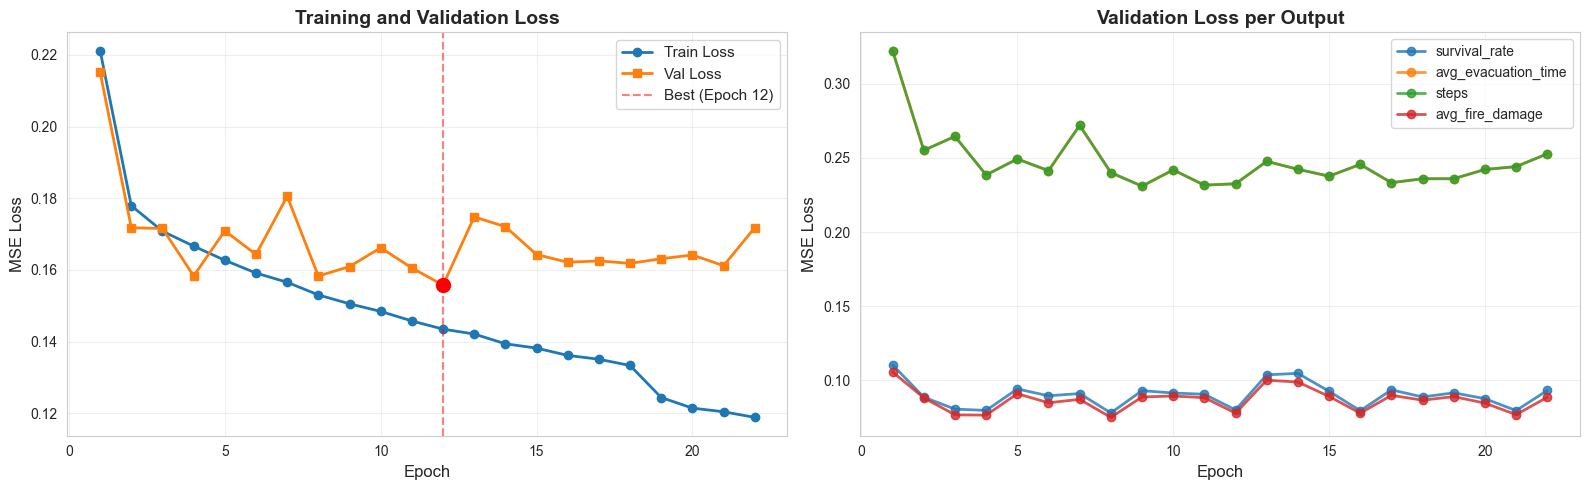


Best validation loss: 0.155750 at epoch 12
Final training loss:  0.118834
Final validation loss: 0.171814


In [7]:
# Load training history
with open(HISTORY_PATH, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

# Plot training and validation loss
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall loss
axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 's-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Best epoch marker
best_epoch = np.argmin(history['val_loss']) + 1
best_val_loss = min(history['val_loss'])
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
axes[0].scatter([best_epoch], [best_val_loss], color='red', s=100, zorder=5)
axes[0].legend(fontsize=11)

# Per-output validation MSE
val_per_output = np.array(history['val_per_output_mse'])
for i, name in enumerate(OUTPUT_NAMES):
    axes[1].plot(epochs, val_per_output[:, i], 'o-', label=name, linewidth=2, alpha=0.8)

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Validation Loss per Output', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'evaluation_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest validation loss: {best_val_loss:.6f} at epoch {best_epoch}")
print(f"Final training loss:  {history['train_loss'][-1]:.6f}")
print(f"Final validation loss: {history['val_loss'][-1]:.6f}")

## 5. Pure Surrogate Evaluation (Test Set)

### 5.1 Compute Test Set Metrics

In [8]:
# Evaluate on test set (normalized)
print("Evaluating model on test set (normalized values)...")
metrics_normalized = evaluate_model(model, test_loader, device, config, denormalize=False)

# Evaluate on test set (denormalized - actual scale)
print("\nEvaluating model on test set (denormalized values)...")
metrics_denormalized = evaluate_model(
    model, test_loader, device, config, 
    denormalize=True, target_stats=stats['target_stats']
)

# Extract predictions and targets for later use
predictions_normalized = metrics_normalized['_raw']['predictions']
targets_normalized = metrics_normalized['_raw']['targets']
predictions_denorm = metrics_denormalized['_raw']['predictions']
targets_denorm = metrics_denormalized['_raw']['targets']

print("\nTest set size:", len(targets_normalized))

Evaluating model on test set (normalized values)...


Evaluating: 100%|██████████| 844/844 [00:32<00:00, 25.67it/s]



Evaluating model on test set (denormalized values)...


Evaluating: 100%|██████████| 844/844 [00:18<00:00, 44.50it/s]


Test set size: 54000


### 5.2 Print Test Metrics

In [9]:
# Print normalized metrics
print("=" * 80)
print("TEST SET EVALUATION (Normalized)")
print("=" * 80)
print("\nOVERALL METRICS:")
overall_norm = metrics_normalized['overall']
print(f"  Overall Mean Loss (MSE): {overall_norm['overall_mean_loss']:.6f}")
print(f"  Mean RMSE:               {overall_norm['mean_rmse']:.6f}")
print(f"  Mean MAE:                {overall_norm['mean_mae']:.6f}")
print(f"  Mean R²:                 {overall_norm['mean_r2']:.6f}")
print(f"  Mean Pearson R:          {overall_norm['mean_pearson_r']:.6f}")

print("\nPER-OUTPUT METRICS:")
print("-" * 80)
print(f"{'Output':<25} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R²':>10} {'Pearson':>10}")
print("-" * 80)
for name in OUTPUT_NAMES:
    m = metrics_normalized[name]
    print(f"{name:<25} {m['mse']:>10.6f} {m['rmse']:>10.6f} {m['mae']:>10.6f} {m['r2']:>10.6f} {m['pearson_r']:>10.6f}")
print("-" * 80)

TEST SET EVALUATION (Normalized)

OVERALL METRICS:
  Overall Mean Loss (MSE): 0.164530
  Mean RMSE:               0.390897
  Mean MAE:                0.245323
  Mean R²:                 0.833139
  Mean Pearson R:          0.917257

PER-OUTPUT METRICS:
--------------------------------------------------------------------------------
Output                           MSE       RMSE        MAE         R²    Pearson
--------------------------------------------------------------------------------
survival_rate               0.080997   0.284599   0.220513   0.918809   0.968576
avg_evacuation_time         0.249190   0.499190   0.270763   0.746334   0.865223
steps                       0.249190   0.499190   0.270763   0.746334   0.865223
avg_fire_damage             0.078742   0.280610   0.219253   0.921081   0.970006
--------------------------------------------------------------------------------


In [10]:
# Print denormalized metrics
print("\n" + "=" * 80)
print("TEST SET EVALUATION (Denormalized - Actual Scale)")
print("=" * 80)
print("\nOVERALL METRICS:")
overall_denorm = metrics_denormalized['overall']
print(f"  Overall Mean Loss (MSE): {overall_denorm['overall_mean_loss']:.6f}")
print(f"  Mean RMSE:               {overall_denorm['mean_rmse']:.6f}")
print(f"  Mean MAE:                {overall_denorm['mean_mae']:.6f}")
print(f"  Mean R²:                 {overall_denorm['mean_r2']:.6f}")
print(f"  Mean Pearson R:          {overall_denorm['mean_pearson_r']:.6f}")

print("\nPER-OUTPUT METRICS:")
print("-" * 80)
print(f"{'Output':<25} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R²':>10} {'Pearson':>10}")
print("-" * 80)
for name in OUTPUT_NAMES:
    m = metrics_denormalized[name]
    print(f"{name:<25} {m['mse']:>10.6f} {m['rmse']:>10.6f} {m['mae']:>10.6f} {m['r2']:>10.6f} {m['pearson_r']:>10.6f}")
print("-" * 80)


TEST SET EVALUATION (Denormalized - Actual Scale)

OVERALL METRICS:
  Overall Mean Loss (MSE): 6.235103
  Mean RMSE:               1.759139
  Mean MAE:                0.974796
  Mean R²:                 0.833139
  Mean Pearson R:          0.917257

PER-OUTPUT METRICS:
--------------------------------------------------------------------------------
Output                           MSE       RMSE        MAE         R²    Pearson
--------------------------------------------------------------------------------
survival_rate               0.005051   0.071069   0.055065   0.918809   0.968576
avg_evacuation_time         4.971813   2.229756   1.209432   0.746334   0.865223
steps                      19.887252   4.459513   2.418863   0.746334   0.865223
avg_fire_damage             0.076297   0.276219   0.215822   0.921081   0.970006
--------------------------------------------------------------------------------


### 5.3 Visualize Predictions vs Targets

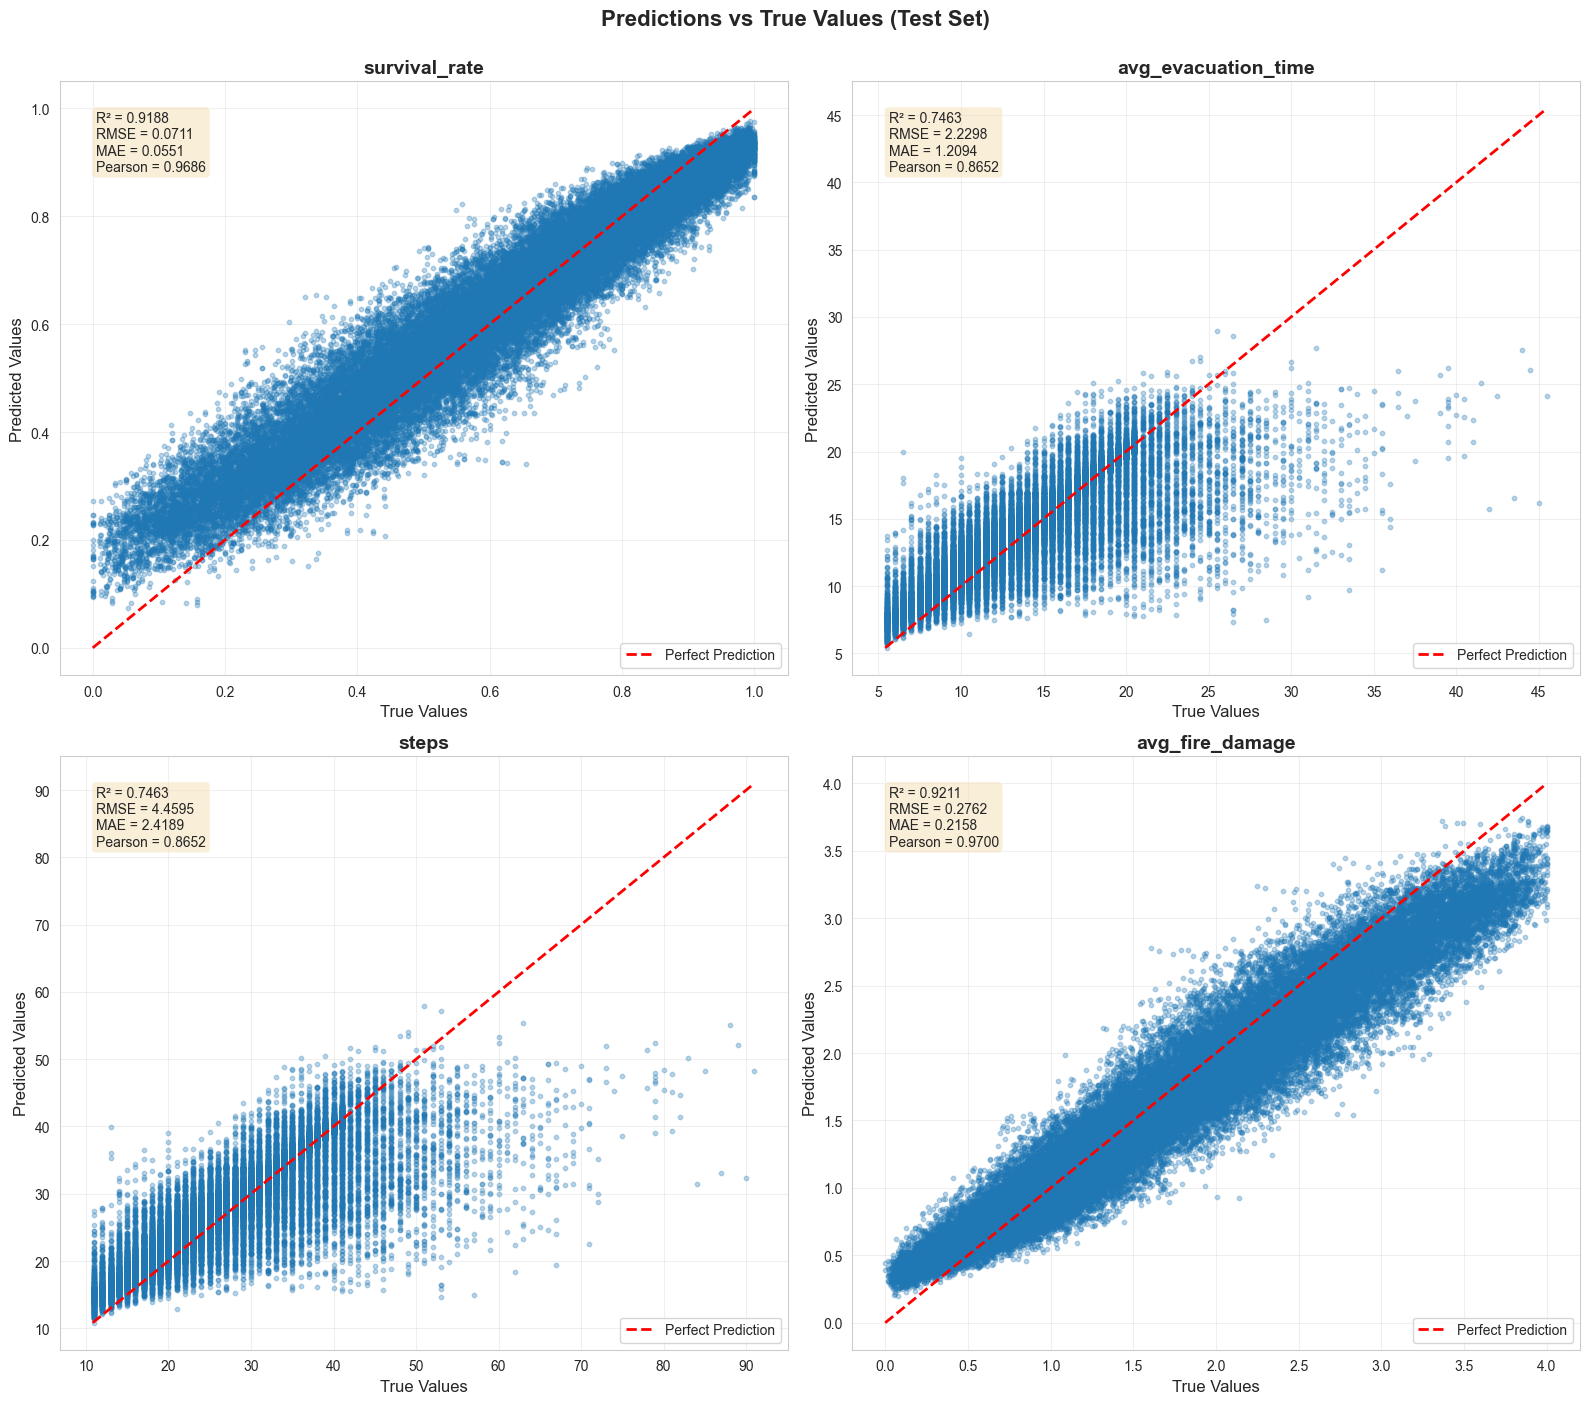

In [11]:
# Scatter plots: Predictions vs Targets (Denormalized)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, name in enumerate(OUTPUT_NAMES):
    ax = axes[i]
    
    y_true = targets_denorm[:, i]
    y_pred = predictions_denorm[:, i]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Metrics
    m = metrics_denormalized[name]
    textstr = f"R² = {m['r2']:.4f}\nRMSE = {m['rmse']:.4f}\nMAE = {m['mae']:.4f}\nPearson = {m['pearson_r']:.4f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('True Values', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predictions vs True Values (Test Set)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'evaluation_predictions_vs_targets.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Error Distribution Analysis

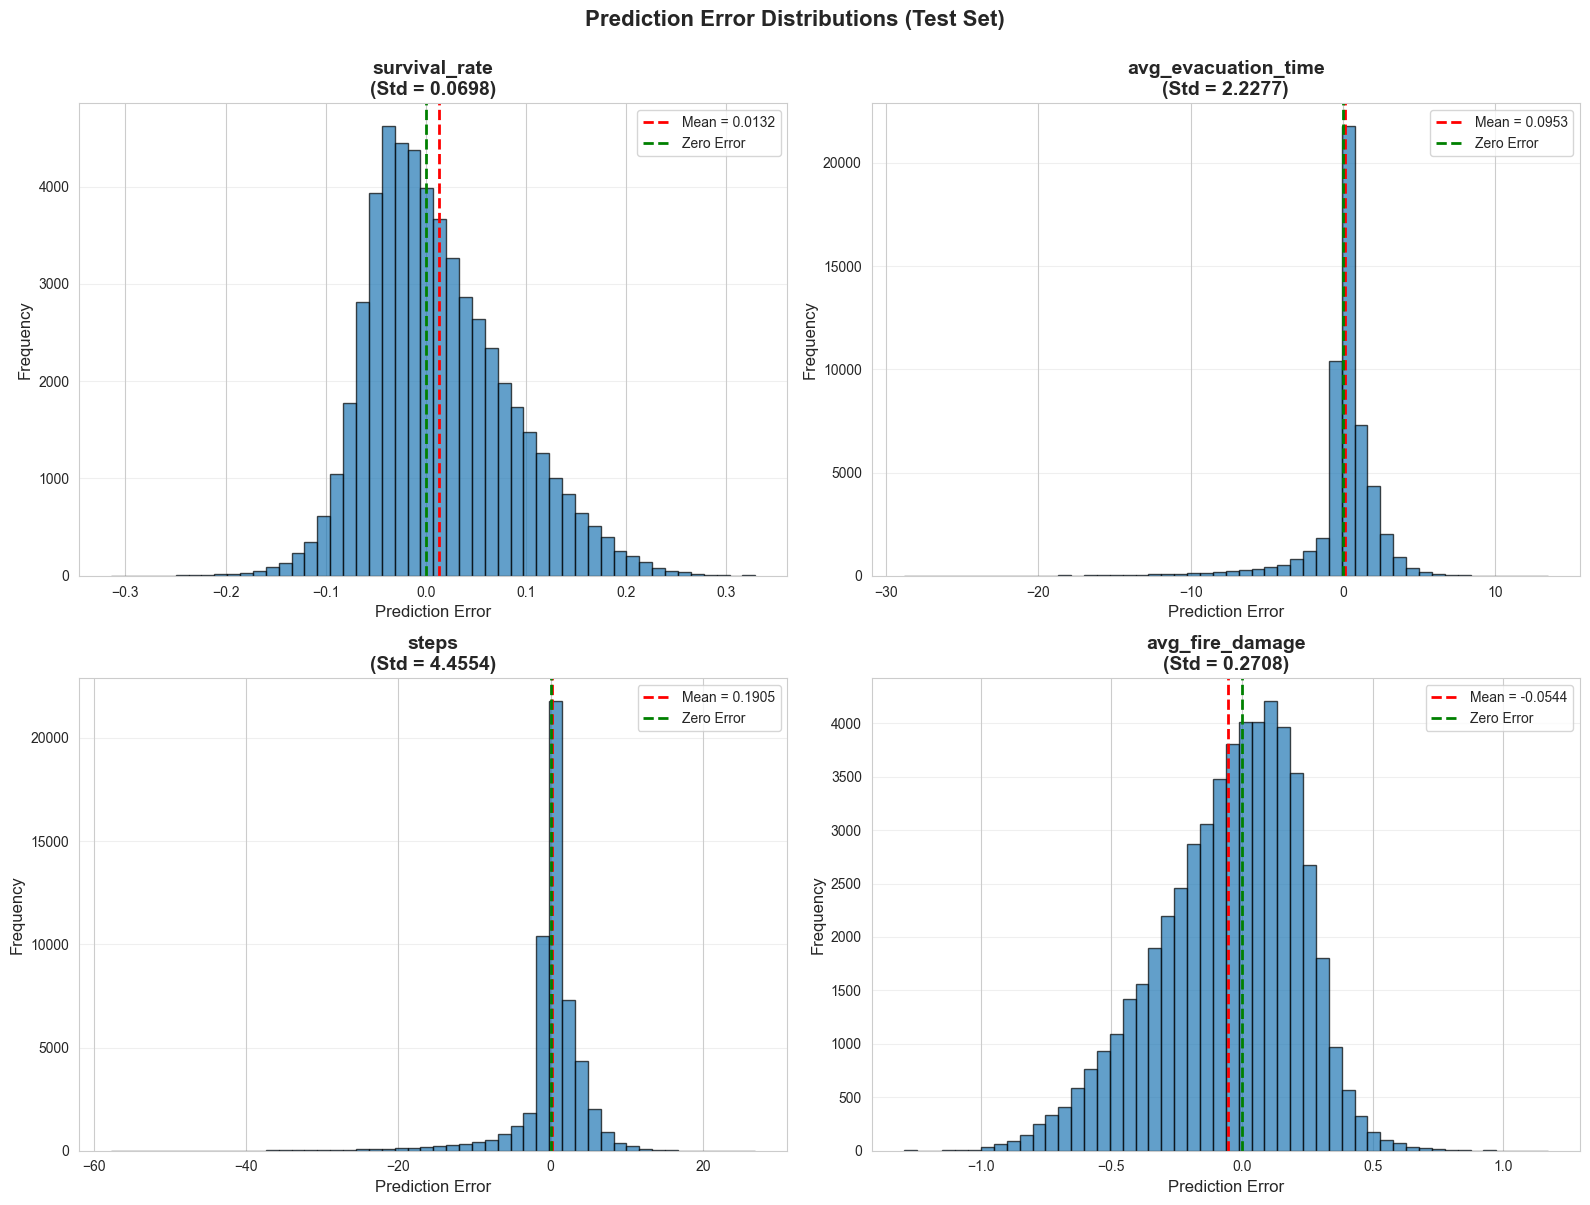

In [12]:
# Error distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(OUTPUT_NAMES):
    ax = axes[i]
    
    y_true = targets_denorm[:, i]
    y_pred = predictions_denorm[:, i]
    errors = y_pred - y_true
    
    # Histogram
    ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
    
    # Statistics
    mean_error = errors.mean()
    std_error = errors.std()
    
    ax.axvline(mean_error, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_error:.4f}')
    ax.axvline(0, color='green', linestyle='--', linewidth=2, label='Zero Error')
    
    ax.set_xlabel('Prediction Error', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{name}\n(Std = {std_error:.4f})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Prediction Error Distributions (Test Set)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'evaluation_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Metrics Summary Visualization

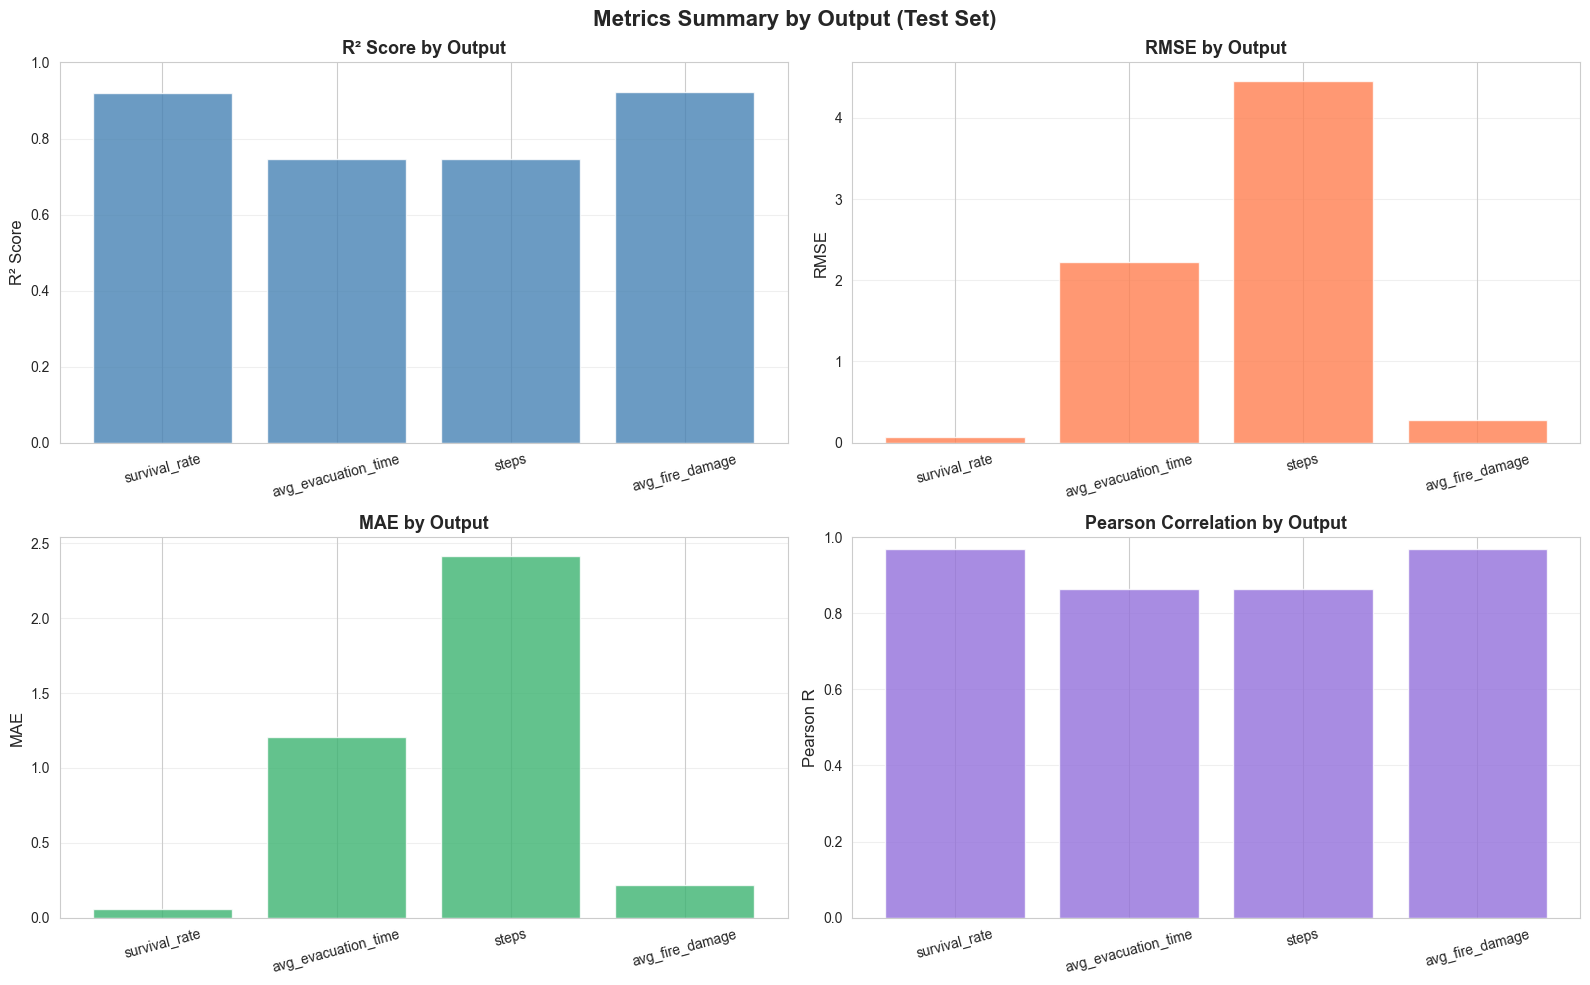

In [13]:
# Bar charts comparing metrics across outputs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# R² scores
r2_scores = [metrics_denormalized[name]['r2'] for name in OUTPUT_NAMES]
axes[0, 0].bar(OUTPUT_NAMES, r2_scores, color='steelblue', alpha=0.8)
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('R² Score by Output', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# RMSE
rmse_scores = [metrics_denormalized[name]['rmse'] for name in OUTPUT_NAMES]
axes[0, 1].bar(OUTPUT_NAMES, rmse_scores, color='coral', alpha=0.8)
axes[0, 1].set_ylabel('RMSE', fontsize=12)
axes[0, 1].set_title('RMSE by Output', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# MAE
mae_scores = [metrics_denormalized[name]['mae'] for name in OUTPUT_NAMES]
axes[1, 0].bar(OUTPUT_NAMES, mae_scores, color='mediumseagreen', alpha=0.8)
axes[1, 0].set_ylabel('MAE', fontsize=12)
axes[1, 0].set_title('MAE by Output', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Pearson correlation
pearson_scores = [metrics_denormalized[name]['pearson_r'] for name in OUTPUT_NAMES]
axes[1, 1].bar(OUTPUT_NAMES, pearson_scores, color='mediumpurple', alpha=0.8)
axes[1, 1].set_ylabel('Pearson R', fontsize=12)
axes[1, 1].set_title('Pearson Correlation by Output', fontsize=13, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Metrics Summary by Output (Test Set)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'evaluation_metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ranking Metrics (Pairwise Comparison)

In [14]:
# Load ranking metrics (if available)
if RANKING_METRICS_PATH.exists():
    with open(RANKING_METRICS_PATH, 'r') as f:
        ranking_metrics = json.load(f)
    
    print("=" * 80)
    print("RANKING EVALUATION (Pairwise Comparison)")
    print("=" * 80)
    print(f"\nPairwise Accuracy:       {ranking_metrics['pairwise_accuracy']:.4f}")
    print(f"AUC-ROC:                 {ranking_metrics['auc_roc']:.4f}")
    print(f"Kendall Tau:             {ranking_metrics['kendall_tau']:.4f}")
    print(f"Spearman R:              {ranking_metrics['spearman_r']:.4f}")
    print(f"Pearson R:               {ranking_metrics['pearson_r']:.4f}")
    print(f"\nTotal pairs evaluated:   {ranking_metrics['total_pairs_evaluated']:,}")
    print(f"Correct predictions:     {ranking_metrics['correct_pairs']:,}")
    print(f"Avg score difference:    {ranking_metrics['avg_score_difference']:.4f}")
    print(f"\nPer-plan statistics:")
    print(f"  Num plans:             {ranking_metrics['num_plans_evaluated']}")
    print(f"  Mean Kendall Tau:      {ranking_metrics['mean_per_plan_kendall_tau']:.4f} ± {ranking_metrics['std_per_plan_kendall_tau']:.4f}")
    print(f"  Mean Spearman R:       {ranking_metrics['mean_per_plan_spearman_r']:.4f} ± {ranking_metrics['std_per_plan_spearman_r']:.4f}")
    print(f"  Top-{ranking_metrics['top_k']} overlap:      {ranking_metrics['mean_top_k_overlap']:.4f}")
else:
    print("Ranking metrics file not found.")
    ranking_metrics = None

RANKING EVALUATION (Pairwise Comparison)

Pairwise Accuracy:       0.8383
AUC-ROC:                 0.9201
Kendall Tau:             0.6678
Spearman R:              0.8606
Pearson R:               0.8405

Total pairs evaluated:   9,967
Correct predictions:     8,355
Avg score difference:    0.3308

Per-plan statistics:
  Num plans:             150
  Mean Kendall Tau:      0.6661 ± 0.0432
  Mean Spearman R:       0.8572 ± 0.0381
  Top-10 overlap:      0.3493


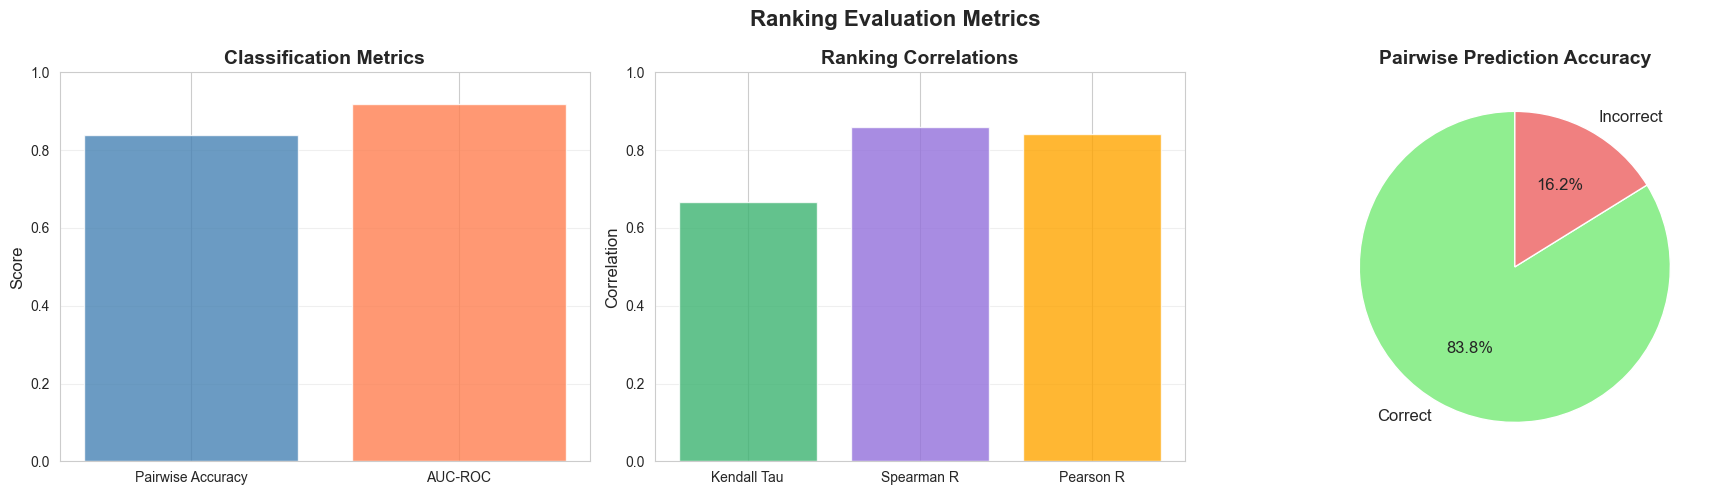

In [15]:
# Visualize ranking metrics
if ranking_metrics is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Pairwise accuracy and AUC
    metrics_data = [
        ranking_metrics['pairwise_accuracy'],
        ranking_metrics['auc_roc']
    ]
    metrics_labels = ['Pairwise Accuracy', 'AUC-ROC']
    colors = ['steelblue', 'coral']
    
    axes[0].bar(metrics_labels, metrics_data, color=colors, alpha=0.8)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('Classification Metrics', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Correlation metrics
    corr_data = [
        ranking_metrics['kendall_tau'],
        ranking_metrics['spearman_r'],
        ranking_metrics['pearson_r']
    ]
    corr_labels = ['Kendall Tau', 'Spearman R', 'Pearson R']
    colors2 = ['mediumseagreen', 'mediumpurple', 'orange']
    
    axes[1].bar(corr_labels, corr_data, color=colors2, alpha=0.8)
    axes[1].set_ylabel('Correlation', fontsize=12)
    axes[1].set_title('Ranking Correlations', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Confusion pie chart
    correct = ranking_metrics['correct_pairs']
    incorrect = ranking_metrics['total_pairs_evaluated'] - correct
    
    axes[2].pie([correct, incorrect], labels=['Correct', 'Incorrect'],
                autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'],
                startangle=90, textprops={'fontsize': 12})
    axes[2].set_title('Pairwise Prediction Accuracy', fontsize=14, fontweight='bold')
    
    plt.suptitle('Ranking Evaluation Metrics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'evaluation_ranking_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. GradCAM Visualizations

### 7.1 Select Random Test Samples for Visualization

In [16]:
# Select random samples from test set
num_viz_samples = 5
np.random.seed(42)
viz_indices = np.random.choice(len(test_loader.dataset), size=num_viz_samples, replace=False)

print(f"Selected {num_viz_samples} random test samples for GradCAM visualization:")
print(f"Indices: {viz_indices.tolist()}")

Selected 5 random test samples for GradCAM visualization:
Indices: [30246, 34164, 40692, 28724, 28097]


### 7.2 Generate GradCAM for Selected Samples

In [17]:
# Create output directory for visualizations
viz_output_dir = CHECKPOINT_DIR / "evaluation_visualizations"
viz_output_dir.mkdir(exist_ok=True)

print(f"Generating GradCAM visualizations...")
print(f"Output directory: {viz_output_dir}")

# Initialize GradCAM
gradcam = SurrogateGradCAM(model)

for idx in tqdm(viz_indices, desc="Generating visualizations"):
    sample = test_loader.dataset[idx]
    grid = sample['grid'].to(device)
    scenario = sample['scenario'].to(device)
    
    # Get predictions
    with torch.no_grad():
        preds = model(grid.unsqueeze(0), scenario.unsqueeze(0))
        predictions = {name: preds[0, i].item() for i, name in enumerate(OUTPUT_NAMES)}
    
    # Generate GradCAM for all outputs
    heatmaps = gradcam.generate_all(grid, scenario)
    
    # Plot and save
    from ml.surrogate.visualize import plot_gradcam_grid
    output_path = viz_output_dir / f"sample_{idx:04d}_gradcam.png"
    plot_gradcam_grid(grid, heatmaps, predictions, output_path=str(output_path), crop_to_content=True)

print(f"\nGradCAM visualizations saved to: {viz_output_dir}")


Generating GradCAM visualizations...
Output directory: c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations


Generating visualizations:   0%|          | 0/5 [00:00<?, ?it/s]c:\dev\Fire_Simulator\ml\surrogate\visualize.py:531: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Generating visualizations:  20%|██        | 1/5 [00:01<00:04,  1.04s/it]

Saved GradCAM visualization to c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations\sample_30246_gradcam.png


Generating visualizations:  40%|████      | 2/5 [00:01<00:02,  1.15it/s]

Saved GradCAM visualization to c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations\sample_34164_gradcam.png


...

Saved GradCAM visualization to c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations\sample_40692_gradcam.png


Generating visualizations:  80%|████████  | 4/5 [00:03<00:00,  1.32it/s]

Saved GradCAM visualization to c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations\sample_28724_gradcam.png


Generating visualizations: 100%|██████████| 5/5 [00:04<00:00,  1.24it/s]

Saved GradCAM visualization to c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations\sample_28097_gradcam.png

GradCAM visualizations saved to: c:\dev\Fire_Simulator\final_surrogate\evaluation_visualizations


### 7.3 Display Sample GradCAM


Sample 30246 - Scenario Parameters:
  Agent count: -0.98
  Num fires: 1.26
  Fire spread rate: 1.66
  Fire discovery delay: -0.79

Predictions vs Targets (normalized):
  survival_rate            : Pred= -0.2596, Target= -0.7593, Error=  0.4997
  avg_evacuation_time      : Pred= -1.0246, Target= -1.1210, Error=  0.0964
  steps                    : Pred= -1.0246, Target= -1.1210, Error=  0.0964
  avg_fire_damage          : Pred=  0.3684, Target=  0.7386, Error= -0.3701


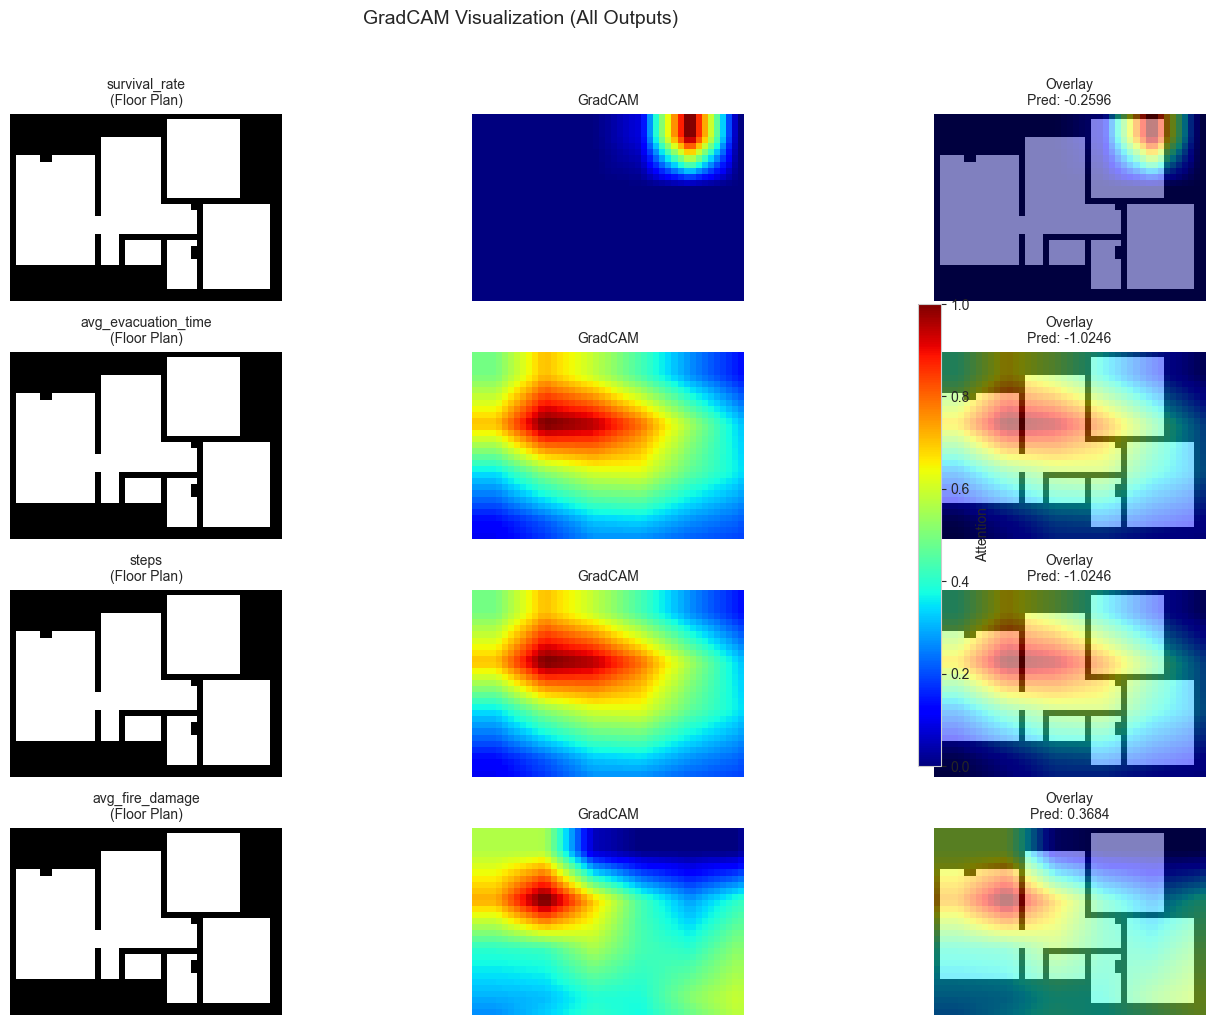

In [18]:
# Display the first sample as an example
sample_idx = viz_indices[0]
sample = test_loader.dataset[sample_idx]
grid = sample['grid'].to(device)
scenario = sample['scenario'].to(device)
targets = sample['targets']

# Get predictions
with torch.no_grad():
    preds = model(grid.unsqueeze(0), scenario.unsqueeze(0))
    predictions = {name: preds[0, i].item() for i, name in enumerate(OUTPUT_NAMES)}
    
print(f"\nSample {sample_idx} - Scenario Parameters:")
print(f"  Agent count: {scenario[0].item():.2f}")
print(f"  Num fires: {scenario[1].item():.2f}")
print(f"  Fire spread rate: {scenario[2].item():.2f}")
print(f"  Fire discovery delay: {scenario[3].item():.2f}")

print(f"\nPredictions vs Targets (normalized):")
for i, name in enumerate(OUTPUT_NAMES):
    print(f"  {name:25s}: Pred={predictions[name]:8.4f}, Target={targets[i].item():8.4f}, Error={predictions[name] - targets[i].item():8.4f}")

# Generate and display GradCAM
heatmaps = gradcam.generate_all(grid, scenario)
from ml.surrogate.visualize import plot_gradcam_grid
plot_gradcam_grid(grid, heatmaps, predictions, output_path=None, crop_to_content=True)

## 8. Summary Report

In [19]:
# Create a comprehensive summary report
print("=" * 80)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("=" * 80)

print(f"\nModel: {MODEL_PATH}")
print(f"Parameters: {model.count_parameters():,}")
print(f"Test set size: {len(test_loader.dataset):,} samples")

print("\n" + "-" * 80)
print("REGRESSION METRICS (Pure Surrogate)")
print("-" * 80)
print(f"Overall Mean MSE:   {overall_denorm['overall_mean_loss']:.6f}")
print(f"Overall Mean RMSE:  {overall_denorm['mean_rmse']:.6f}")
print(f"Overall Mean MAE:   {overall_denorm['mean_mae']:.6f}")
print(f"Overall Mean R²:    {overall_denorm['mean_r2']:.6f}")
print(f"Overall Pearson R:  {overall_denorm['mean_pearson_r']:.6f}")

print("\nPer-output R² scores:")
for name in OUTPUT_NAMES:
    print(f"  {name:25s}: {metrics_denormalized[name]['r2']:.4f}")

if ranking_metrics is not None:
    print("\n" + "-" * 80)
    print("RANKING METRICS (Pairwise Comparison)")
    print("-" * 80)
    print(f"Pairwise Accuracy:  {ranking_metrics['pairwise_accuracy']:.4f}")
    print(f"AUC-ROC:            {ranking_metrics['auc_roc']:.4f}")
    print(f"Kendall Tau:        {ranking_metrics['kendall_tau']:.4f}")
    print(f"Spearman R:         {ranking_metrics['spearman_r']:.4f}")

print("\n" + "-" * 80)
print("TRAINING HISTORY")
print("-" * 80)
print(f"Total epochs:       {len(history['train_loss'])}")
print(f"Best epoch:         {best_epoch}")
print(f"Best val loss:      {best_val_loss:.6f}")
print(f"Final train loss:   {history['train_loss'][-1]:.6f}")
print(f"Final val loss:     {history['val_loss'][-1]:.6f}")

print("\n" + "=" * 80)
print("VISUALIZATIONS GENERATED")
print("=" * 80)
print(f"- Training history: evaluation_training_history.png")
print(f"- Predictions vs targets: evaluation_predictions_vs_targets.png")
print(f"- Error distributions: evaluation_error_distributions.png")
print(f"- Metrics summary: evaluation_metrics_summary.png")
if ranking_metrics is not None:
    print(f"- Ranking metrics: evaluation_ranking_metrics.png")
print(f"- GradCAM visualizations: evaluation_visualizations/sample_*_gradcam.png")
print("\nAll files saved to:", CHECKPOINT_DIR)
print("=" * 80)

COMPREHENSIVE EVALUATION SUMMARY

Model: c:\dev\Fire_Simulator\final_surrogate\best_model.pt
Parameters: 1,490,500
Test set size: 54,000 samples

--------------------------------------------------------------------------------
REGRESSION METRICS (Pure Surrogate)
--------------------------------------------------------------------------------
Overall Mean MSE:   6.235103
Overall Mean RMSE:  1.759139
Overall Mean MAE:   0.974796
Overall Mean R²:    0.833139
Overall Pearson R:  0.917257

Per-output R² scores:
  survival_rate            : 0.9188
  avg_evacuation_time      : 0.7463
  steps                    : 0.7463
  avg_fire_damage          : 0.9211

--------------------------------------------------------------------------------
RANKING METRICS (Pairwise Comparison)
--------------------------------------------------------------------------------
Pairwise Accuracy:  0.8383
AUC-ROC:            0.9201
Kendall Tau:        0.6678
Spearman R:         0.8606

----------------------------------

## 9. Save Evaluation Results

In [20]:
# Save evaluation metrics to JSON
evaluation_results = {
    'model_path': str(MODEL_PATH),
    'test_size': len(test_loader.dataset),
    'model_parameters': model.count_parameters(),
    'regression_metrics_normalized': {
        'overall': overall_norm,
        'per_output': {name: metrics_normalized[name] for name in OUTPUT_NAMES}
    },
    'regression_metrics_denormalized': {
        'overall': overall_denorm,
        'per_output': {name: metrics_denormalized[name] for name in OUTPUT_NAMES}
    },
    'training_history': {
        'total_epochs': len(history['train_loss']),
        'best_epoch': int(best_epoch),
        'best_val_loss': float(best_val_loss),
        'final_train_loss': float(history['train_loss'][-1]),
        'final_val_loss': float(history['val_loss'][-1])
    }
}

if ranking_metrics is not None:
    evaluation_results['ranking_metrics'] = ranking_metrics

# Save to file
eval_results_path = CHECKPOINT_DIR / 'evaluation_results.json'
with open(eval_results_path, 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f"Evaluation results saved to: {eval_results_path}")

Evaluation results saved to: c:\dev\Fire_Simulator\final_surrogate\evaluation_results.json


## 10. Additional Analysis (Optional)

### 10.1 Worst Predictions Analysis

In [21]:
# Find worst predictions for each output
print("Top 5 Worst Predictions per Output:\n")

for i, name in enumerate(OUTPUT_NAMES):
    errors = np.abs(predictions_denorm[:, i] - targets_denorm[:, i])
    worst_indices = np.argsort(errors)[-5:][::-1]
    
    print(f"{name}:")
    print("-" * 60)
    for rank, idx in enumerate(worst_indices, 1):
        true_val = targets_denorm[idx, i]
        pred_val = predictions_denorm[idx, i]
        error = pred_val - true_val
        print(f"  {rank}. Sample {idx:5d}: True={true_val:8.4f}, Pred={pred_val:8.4f}, Error={error:8.4f}")
    print()

Top 5 Worst Predictions per Output:

survival_rate:
------------------------------------------------------------
  1. Sample 38605: True=  0.3208, Pred=  0.6497, Error=  0.3290
  2. Sample 31695: True=  0.2308, Pred=  0.5517, Error=  0.3210
  3. Sample 31719: True=  0.2308, Pred=  0.5486, Error=  0.3178
  4. Sample 37837: True=  0.3378, Pred=  0.6549, Error=  0.3170
  5. Sample 17191: True=  0.6545, Pred=  0.3403, Error= -0.3142

avg_evacuation_time:
------------------------------------------------------------
  1. Sample 49307: True= 45.0000, Pred= 16.1631, Error=-28.8369
  2. Sample 35279: True= 43.5000, Pred= 16.5635, Error=-26.9365
  3. Sample 35278: True= 42.0000, Pred= 15.7102, Error=-26.2898
  4. Sample 37592: True= 35.5000, Pred= 11.2288, Error=-24.2712
  5. Sample  1395: True= 33.5000, Pred=  9.6842, Error=-23.8158

steps:
------------------------------------------------------------
  1. Sample 49307: True= 90.0000, Pred= 32.3262, Error=-57.6738
  2. Sample 35279: True= 87.000

### 10.2 Best Predictions Analysis

In [22]:
# Find best predictions for each output
print("Top 5 Best Predictions per Output:\n")

for i, name in enumerate(OUTPUT_NAMES):
    errors = np.abs(predictions_denorm[:, i] - targets_denorm[:, i])
    best_indices = np.argsort(errors)[:5]
    
    print(f"{name}:")
    print("-" * 60)
    for rank, idx in enumerate(best_indices, 1):
        true_val = targets_denorm[idx, i]
        pred_val = predictions_denorm[idx, i]
        error = pred_val - true_val
        print(f"  {rank}. Sample {idx:5d}: True={true_val:8.4f}, Pred={pred_val:8.4f}, Error={error:8.4f}")
    print()

Top 5 Best Predictions per Output:

survival_rate:
------------------------------------------------------------
  1. Sample 18887: True=  0.4000, Pred=  0.4000, Error=  0.0000
  2. Sample 53627: True=  0.8129, Pred=  0.8129, Error=  0.0000
  3. Sample 22640: True=  0.7269, Pred=  0.7269, Error= -0.0000
  4. Sample 49945: True=  0.4711, Pred=  0.4711, Error=  0.0000
  5. Sample 14440: True=  0.5185, Pred=  0.5185, Error= -0.0000

avg_evacuation_time:
------------------------------------------------------------
  1. Sample 12134: True= 18.5000, Pred= 18.5000, Error= -0.0000
  2. Sample 50388: True= 15.5000, Pred= 15.5000, Error= -0.0000
  3. Sample 32004: True= 11.5000, Pred= 11.5001, Error=  0.0001
  4. Sample 38469: True= 15.5000, Pred= 15.5001, Error=  0.0001
  5. Sample 22562: True= 16.0000, Pred= 15.9999, Error= -0.0001

steps:
------------------------------------------------------------
  1. Sample 12134: True= 37.0000, Pred= 37.0000, Error= -0.0000
  2. Sample 50388: True= 31.0000

## Done!

This notebook has completed a comprehensive evaluation of your Fire Simulation Surrogate Model.

All results and visualizations have been saved to the checkpoints directory.